# Evolución de patrimonio - Depósito a Plazo

In [55]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

FILE='F022CAPTIND089NOZM.xlsx'
INITIAL_CAPITAL=350_000
MONTHLY_CONTRIBUTION=10_000


## Cargamos las tasas del banco central

In [56]:
raw=pd.read_excel(FILE,header=None)

# Buscar fila que contiene la fecha
start=None
for i,row in raw.iterrows():
    vals=row.astype(str).str.lower()
    if vals.str.contains('periodo').any() or vals.str.contains('fecha').any():
        start=i
        break
if start is None:
    raise ValueError("No se encontró la fila de encabezados.")

dfSource=pd.read_excel(FILE,skiprows=start)
dfSource=dfSource.iloc[:,:2]
dfSource.columns=['Periodo','Tasa anual']
# dfSource=dfSource.dropna()
dfSource['Periodo']=pd.to_datetime(dfSource['Periodo'])
dfSource['Tasa anual']=pd.to_numeric(dfSource['Tasa anual'],errors='coerce')

dfSource.head()

,Periodo,Tasa anual
0,1982-01-01,38.76
1,1982-02-01,33.24
2,1982-03-01,28.68
3,1982-04-01,25.92
4,1982-05-01,29.52


## Graficamos

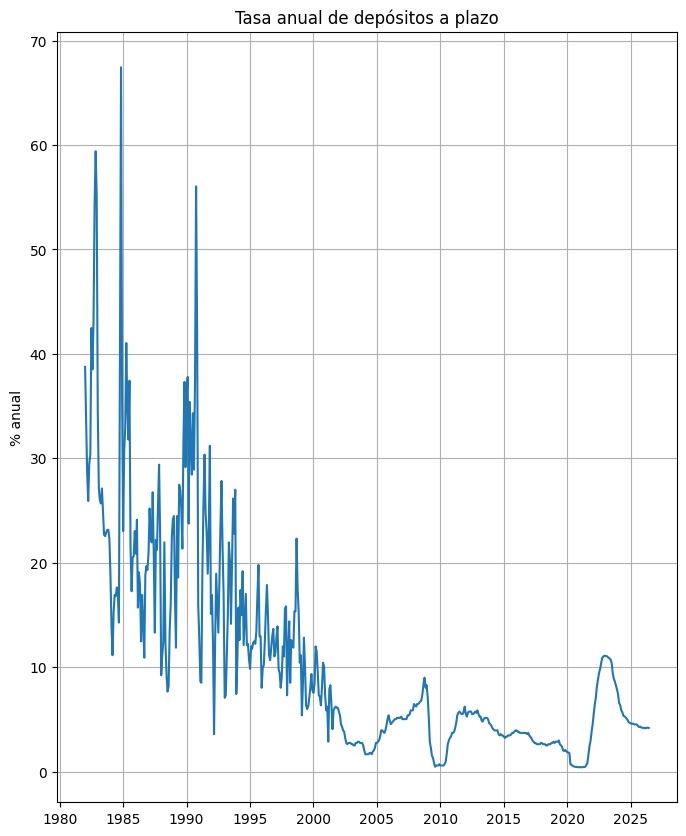

In [57]:
plt.figure(figsize=(8,10))
plt.plot(dfSource["Periodo"], dfSource["Tasa anual"])
plt.title("Tasa anual de depósitos a plazo")
plt.ylabel("% anual")
plt.grid(True)
plt.show()

## Configuramos el periodo

In [58]:
# df = dfSource.dropna()
df = dfSource.query("Periodo>='2008-01-01'")

# porcentaje anual -> decimal mensual
df['Tasa mensual']=(df['Tasa anual']/100)/12

capital=INITIAL_CAPITAL
rows=[]
for _,r in df.iterrows():
    start_cap=capital
    capital+=MONTHLY_CONTRIBUTION
    interest=capital*r['Tasa mensual']
    capital+=interest
    rows.append([r['Periodo'],start_cap,MONTHLY_CONTRIBUTION,r['Tasa mensual'],interest,capital])

equity=pd.DataFrame(rows,columns=['Periodo','Capital inicial','Aporte mensual','Tasa mensual','Interes','Capital final'])
equity.tail()

/tmp/ipykernel_1562/3598402703.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Tasa mensual']=(df['Tasa anual']/100)/12


,Periodo,Capital inicial,Aporte mensual,Tasa mensual,Interes,Capital final
217,2026-02-01,4.082777e+06,10000,0.003467,14188.294687,4.106966e+06
218,2026-03-01,4.106966e+06,10000,0.003508,14443.687675,4.131409e+06
219,2026-04-01,4.131409e+06,10000,0.003492,14460.420791,4.155870e+06
220,2026-05-01,4.155870e+06,10000,0.003525,14684.690751,4.180554e+06
221,2026-06-01,4.180554e+06,10000,0.003492,14632.019139,4.205186e+06


In [59]:
equity.head()

,Periodo,Capital inicial,Aporte mensual,Tasa mensual,Interes,Capital final
0,2008-01-01,350000.000000,10000,0.0053,1908.000000,361908.000000
1,2008-02-01,361908.000000,10000,0.0052,1933.921600,373841.921600
2,2008-03-01,373841.921600,10000,0.0054,2072.746377,385914.667977
3,2008-04-01,385914.667977,10000,0.0054,2137.939207,398052.607184
4,2008-05-01,398052.607184,10000,0.0055,2244.289340,410296.896523


## Graficamos la curva de patrimonio

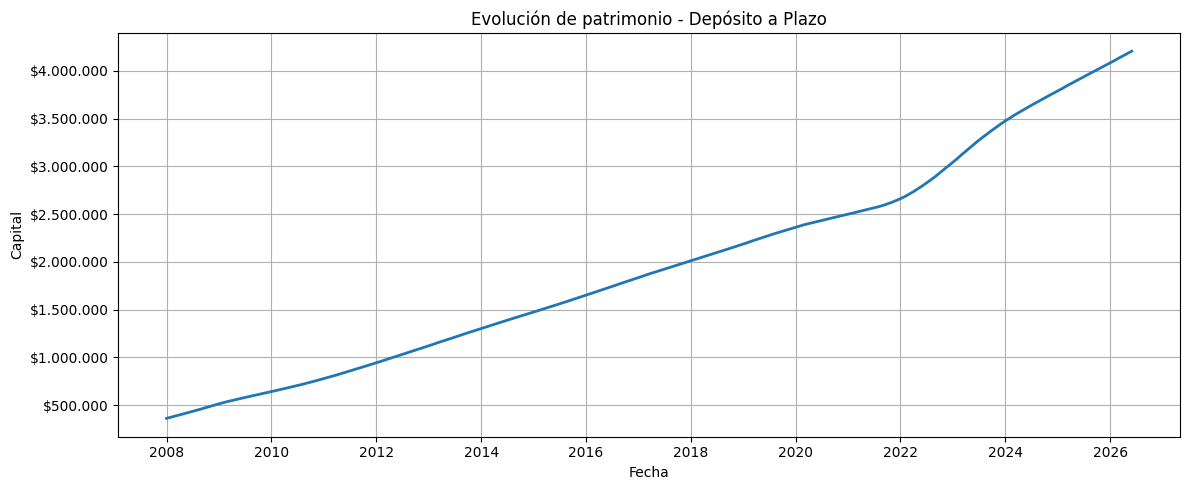

In [60]:


def formato_clp(x, pos):
    return f"${x:,.0f}".replace(",", ".")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(equity['Periodo'], equity['Capital final'], linewidth=2)

ax.set_title('Evolución de patrimonio - Depósito a Plazo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Capital')

# Formato de moneda chilena
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))

ax.grid(True)

plt.tight_layout()
plt.show()

## Proyección

In [61]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Base
df = dfSource.copy()
df['Periodo'] = pd.to_datetime(df['Periodo'])
df = df.query("Periodo >= '2008-01-01'").sort_values('Periodo').copy()

last_real_date = df['Periodo'].max()  # o algún otro marcador

# Índice mensual para la regresión
df['t_idx'] = np.arange(len(df))

# Regresión lineal sobre la tasa anual para proyectar meses futuros
model_rate = LinearRegression()
X_rate = df[['t_idx']]
y_rate = df['Tasa anual']
model_rate.fit(X_rate, y_rate)

# Extender calendario hasta 2030-12
future_periods = pd.date_range(
    start=df['Periodo'].max() + pd.offsets.MonthBegin(1),
    end='2030-12-01',
    freq='MS'
)

df_future = pd.DataFrame({'Periodo': future_periods})
df_future['t_idx'] = np.arange(len(df), len(df) + len(df_future))

# Predecir tasa anual futura
df_future['Tasa anual'] = model_rate.predict(df_future[['t_idx']])

# Opcional: evitar tasas negativas
df_future['Tasa anual'] = df_future['Tasa anual'].clip(lower=0)

# Unir histórico + futuro
df_extended = pd.concat(
    [df[['Periodo', 'Tasa anual', 't_idx']], df_future[['Periodo', 'Tasa anual', 't_idx']]],
    ignore_index=True
).sort_values('Periodo').reset_index(drop=True)

# porcentaje anual -> decimal mensual
df_extended['Tasa mensual'] = (df_extended['Tasa anual'] / 100) / 12

# Simulación de capital
capital = INITIAL_CAPITAL
rows = []

for _, r in df_extended.iterrows():
    start_cap = capital
    capital += MONTHLY_CONTRIBUTION
    interest = capital * r['Tasa mensual']
    capital += interest

    rows.append([
        r['Periodo'],
        start_cap,
        MONTHLY_CONTRIBUTION,
        r['Tasa anual'],
        r['Tasa mensual'],
        interest,
        capital
    ])

equity = pd.DataFrame(
    rows,
    columns=[
        'Periodo',
        'Capital inicial',
        'Aporte mensual',
        'Tasa anual',
        'Tasa mensual',
        'Interes',
        'Capital final'
    ]
)

# Regresión lineal sobre Capital final
equity['t_idx'] = np.arange(len(equity))

model_capital = LinearRegression()
X_cap = equity[['t_idx']]
y_cap = equity['Capital final']
model_capital.fit(X_cap, y_cap)

equity['Capital final pronosticado'] = model_capital.predict(X_cap)

equity.tail()

,Periodo,Capital inicial,Aporte mensual,Tasa anual,Tasa mensual,Interes,Capital final,t_idx,Capital final pronosticado
271,2030-08-01,5.706958e+06,10000,5.168975,0.004307,24625.679074,5.741584e+06,271,5.139358e+06
272,2030-09-01,5.741584e+06,10000,5.174588,0.004312,24801.726903,5.776385e+06,272,5.158637e+06
273,2030-10-01,5.776385e+06,10000,5.180200,0.004317,24978.858570,5.811364e+06,273,5.177916e+06
274,2030-11-01,5.811364e+06,10000,5.185812,0.004322,25157.081227,5.846521e+06,274,5.197196e+06
275,2030-12-01,5.846521e+06,10000,5.191424,0.004326,25336.402080,5.881858e+06,275,5.216475e+06


In [62]:
equity.head()

,Periodo,Capital inicial,Aporte mensual,Tasa anual,Tasa mensual,Interes,Capital final,t_idx,Capital final pronosticado
0,2008-01-01,350000.000000,10000,6.36,0.0053,1908.000000,361908.000000,0,-85316.755277
1,2008-02-01,361908.000000,10000,6.24,0.0052,1933.921600,373841.921600,1,-66037.512666
2,2008-03-01,373841.921600,10000,6.48,0.0054,2072.746377,385914.667977,2,-46758.270056
3,2008-04-01,385914.667977,10000,6.48,0.0054,2137.939207,398052.607184,3,-27479.027445
4,2008-05-01,398052.607184,10000,6.60,0.0055,2244.289340,410296.896523,4,-8199.784835


In [63]:
equity["Aporte mensual"].sum()

np.int64(2760000)

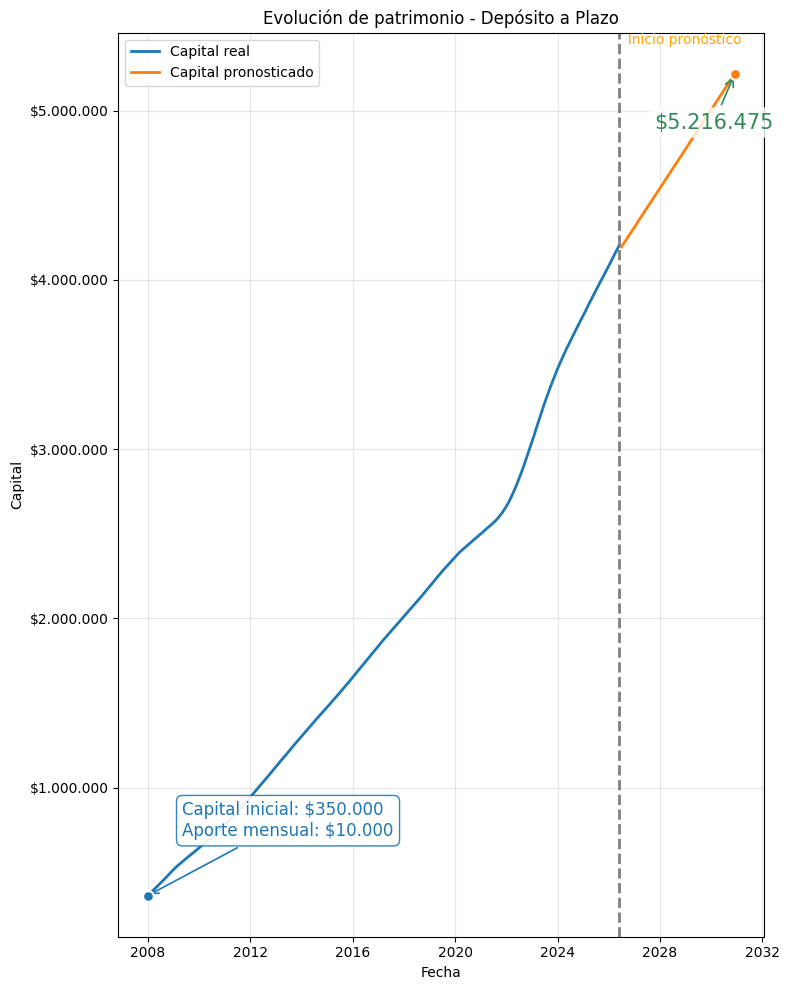

In [65]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

equity = equity.sort_values('Periodo').reset_index(drop=True)

mask_real = equity['Periodo'] <= last_real_date
mask_forecast = equity['Periodo'] > last_real_date

fig, ax = plt.subplots(figsize=(8, 10))

# Serie real
ax.plot(
    equity.loc[mask_real, 'Periodo'],
    equity.loc[mask_real, 'Capital final'],
    color='tab:blue',
    linewidth=2,
    label='Capital real'
)

# Serie pronosticada
ax.plot(
    equity.loc[mask_forecast, 'Periodo'],
    equity.loc[mask_forecast, 'Capital final pronosticado'],
    color='tab:orange',
    linewidth=2,
    label='Capital pronosticado'
)

# Corte pronóstico
ax.axvline(last_real_date, color='gray', linestyle='--', linewidth=2)
ax.text(
    last_real_date,
    ax.get_ylim()[1],
    '  Inicio pronóstico',
    va='top',
    ha='left',
    color='orange'
)

# Último punto pronosticado
x_last = equity.loc[mask_forecast, 'Periodo'].iloc[-1]
y_last = equity.loc[mask_forecast, 'Capital final pronosticado'].iloc[-1]

ax.scatter(
    x_last,
    y_last,
    s=60,
    color='tab:orange',
    edgecolor='white',
    linewidth=1.5,
    zorder=5
)

label_final = f"${y_last:,.0f}".replace(",", ".")

ax.annotate(
    label_final,
    xy=(x_last, y_last),
    xytext=(-15, -35),
    textcoords='offset points',
    color='seagreen',
    fontsize=15,
    ha='center',
    va='center',
    arrowprops=dict(
        arrowstyle='->',
        color='seagreen',
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.25',
        fc='white',
        ec='none',
        alpha=0.8
    )
)

# Primer punto real
x0 = equity.loc[mask_real, 'Periodo'].iloc[0]
y0 = equity.loc[mask_real, 'Capital final'].iloc[0]

ax.scatter(
    x0,
    y0,
    s=60,
    color='tab:blue',
    edgecolor='white',
    linewidth=1.5,
    zorder=5
)

label_inicio = (
    f"Capital inicial: ${INITIAL_CAPITAL:,.0f}\n"
    f"Aporte mensual: ${MONTHLY_CONTRIBUTION:,.0f}"
).replace(",", ".")

ax.annotate(
    label_inicio,
    xy=(x0, y0),
    xytext=(25, 40),
    textcoords='offset points',
    color='tab:blue',
    fontsize=12,
    ha='left',
    va='bottom',
    multialignment='left',
    arrowprops=dict(
        arrowstyle='->',
        color='tab:blue',
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        fc='white',
        ec='tab:blue',
        alpha=0.9
    )
)

ax.set_title('Evolución de patrimonio - Depósito a Plazo')
ax.set_xlabel('Fecha')
ax.set_ylabel('Capital')
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()